# Chargement des modules

In [75]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re as re

# Fonctions réutilisées

In [76]:
def compute_shape_and_size(df: pd.DataFrame, df_name:str):
    print(f"Le fichier {df_name} comporte {df.shape[0]} lignes et {df.shape[1]} colonnes. \n"
          f"Le nombre d'élément est de {df.size}")


def compute_number_of_unique_entries(df: pd.DataFrame):
    unique_entries = (~df.duplicated()).values.sum()
    total_entries = df.shape[0]
    proportion_doublons = int((1 - (unique_entries / total_entries)) * 100)
    print(f"Le nombre d'entrée unique est de {unique_entries}, sur {total_entries} entrées au total. Soit { proportion_doublons}% de doublons")

def compute_prop_missing_values(df: pd.DataFrame):
    return  np.round((df.sum(axis=0) / df.shape[0]) * 100, 1)

def compute_and_plot_missing_values(df : pd.DataFrame):
            
    missing_values = df.isnull().astype("float")
    # Je veux calculer maintenant les proportions avant de modifier en place le dataframe.
    # Je trouve le fonctionnement suivant plus pratique : Je traite -> Je calcule les proportion -> Je dessine 
    prop_missing = compute_prop_missing_values(missing_values)

    missing_values = missing_values.replace(to_replace = 0, value= np.nan)

    ax = msno.bar(missing_values)
    fig = ax.get_figure()

# Missingno's 
    ax_proportion = fig.axes[0]
    ax_count = fig.axes[1]
    ax_dlabels = fig.axes[2]

# Show the proportion axis
    ax_proportion.yaxis.set_visible(True)
    ax_proportion.spines["right"].set_visible(True)
    ax_proportion.spines["left"].set_visible(True)
    ax_proportion.yaxis.set_ticks_position("left")
    ax_proportion.yaxis.set_label_position("left")
    ax_proportion.set_ylabel("Proportion", fontsize = 16)
    ax_proportion.grid(visible=True, color = "grey", which="major")
    

# Hide the count axis
    ax_count.yaxis.set_visible(False)
    ax_count.spines["right"].set_visible(False)
    ax_count.spines["left"].set_visible(False)
    ax_count.yaxis.set_ticks_position("left")
    ax_count.yaxis.set_label_position("left")
    
    ax_dlabels.set_xticks(ax.get_xticks())
    ax_dlabels.tick_params(rotation=0, top=True)
    ax.set_title("Missing values by column", fontsize = 20)
    
    fig.tight_layout()
    plt.show()

    return prop_missing


def get_columns_to_delete(ds: pd.Series, n : float = 75.0):
    mask = ds >= n
    return ds[mask].dropna().index 

def count_cat_occurences(df: pd.DataFrame):
    litteral_columns = list(df.select_dtypes("object").columns)

    occurences = {}
    for col in litteral_columns:
        occurences[col] = df[col].value_counts()

    return occurences


# Etape 1 - Chargement des fichiers dans le Notebook

In [77]:
def is_csv(filepath: str):
    ext = os.path.splitext(filepath)[1].lower()
    return ext == ".csv"

cwd = os.path.join(os.getcwd(), "data") # cwd est un objet DirEntry, on peut accéder au path via l'attribut

dfs_container = {}  # stockera les dfs chargés

for element in os.scandir(cwd):
    if element.is_file() and is_csv(element.path):
        *_, file_name, _ = re.split( r'[/.]', element.path)
        df = pd.read_csv(element.path)
        dfs_container[file_name] = df

In [78]:
display(dfs_container["EdStatsData"])

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Explication : Je n'avais pas envie d'écrire 5 read_csv("csv_file_path").

Les DataFrames sont chargés et mis dans une liste. La longueur de la liste est de 5, j'ai donc bien tous les fichiers demandés.


# Etape 2 - A la recherche d'information

Objectifs : 

    - Comprendre l'organisation de chaque DataFrame (head, info, shape)
    
    - Identifier les liens éventuels entre chaque (colonne identique à travers les DF)
    
    - Tirer le maximum d'information (unique, value_counts, describe?, duplicated) 
    

## Analyse préliminaire
En analyse préliminaire, nous pouvons regarder comment chaque DataFrame est organisé.

In [79]:
for _, (key, df) in enumerate(dfs_container.items()):
    compute_shape_and_size(df, key)
    print("\n")

Le fichier EdStatsCountry comporte 241 lignes et 32 colonnes. 
Le nombre d'élément est de 7712


Le fichier EdStatsData comporte 886930 lignes et 70 colonnes. 
Le nombre d'élément est de 62085100


Le fichier EdStatsSeries comporte 3665 lignes et 21 colonnes. 
Le nombre d'élément est de 76965


Le fichier EdStatsCountry-Series comporte 613 lignes et 4 colonnes. 
Le nombre d'élément est de 2452


Le fichier EdStatsFootNote comporte 643638 lignes et 5 colonnes. 
Le nombre d'élément est de 3218190




Etant donné les différences notables d'organisation et de nombre d'éléments entre chaque DataFrame, nous allons les regarder un par un pour comprendre ce qu'ils représentent.

## Premier dataset

In [80]:
country_df = dfs_container["EdStatsCountry"]
country_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 32 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country Code                                       241 non-null    object 
 1   Short Name                                         241 non-null    object 
 2   Table Name                                         241 non-null    object 
 3   Long Name                                          241 non-null    object 
 4   2-alpha code                                       238 non-null    object 
 5   Currency Unit                                      215 non-null    object 
 6   Special Notes                                      145 non-null    object 
 7   Region                                             214 non-null    object 
 8   Income Group                                       214 non-null    object 
 9   WB-2 code 

In [81]:
country_df.describe()

,National accounts reference year,Latest industrial data,Latest trade data,Unnamed: 31
count,32.00000,107.000000,185.000000,0.0
mean,2001.53125,2008.102804,2010.994595,NaN
std,5.24856,2.616834,2.569675,NaN
min,1987.00000,2000.000000,1995.000000,NaN
25%,1996.75000,2007.500000,2011.000000,NaN
50%,2002.00000,2009.000000,2012.000000,NaN
75%,2005.00000,2010.000000,2012.000000,NaN
max,2012.00000,2010.000000,2012.000000,NaN


En première analyse, nous identifions 241 lignes faisant référence à des pays. Les attributs de ces pays sont au nombre de 32, avec 28 de type littéral (object -> str), et 4 de type numérique (float64). 

Néanmoins, plusieurs observations sont possibles à partir des méthodes .head() et .infos() : 

- Les attributs de format numérique semblent correspondre à des années où certaines actions étatiques ont été effectuées pour la dernière fois. C'est le cas pour les attributs Latest trade data, Latest industrial data, National accounts reference year.
- La dernière colonne (Unnamed: 31), bien qu'au format numérique, est vide (0 non-null valeurs).
- Le nombre de données diffère grandement entre pays, avec par exemple 238 entrées pour l'attribut 2-alpha code, et 32 pour le National accounts reference year.

De ces informations, je peux à présent regarder le nombre de doublons, s'ils existent, supprimer la colonne inutilisable, et calculer la proportion de valeurs manquantes par colonnes.


In [82]:
compute_number_of_unique_entries(country_df)

Le nombre d'entrée unique est de 241, sur 241 entrées au total. Soit 0% de doublons


Avec la première information, nous pouvons voir que toutes les entrées du premier attribut sont uniques. Etant donné que cet attribut correspond à la désignation d'un pays, chaque entrée correspond bien à un pays distinct.


Supprimons à présent la colonne inutilisable

In [83]:
country_df.drop(columns={"Unnamed: 31"}, inplace=True)

Calculons maintenant la proportion de valeurs manquantes dans chaque attribut

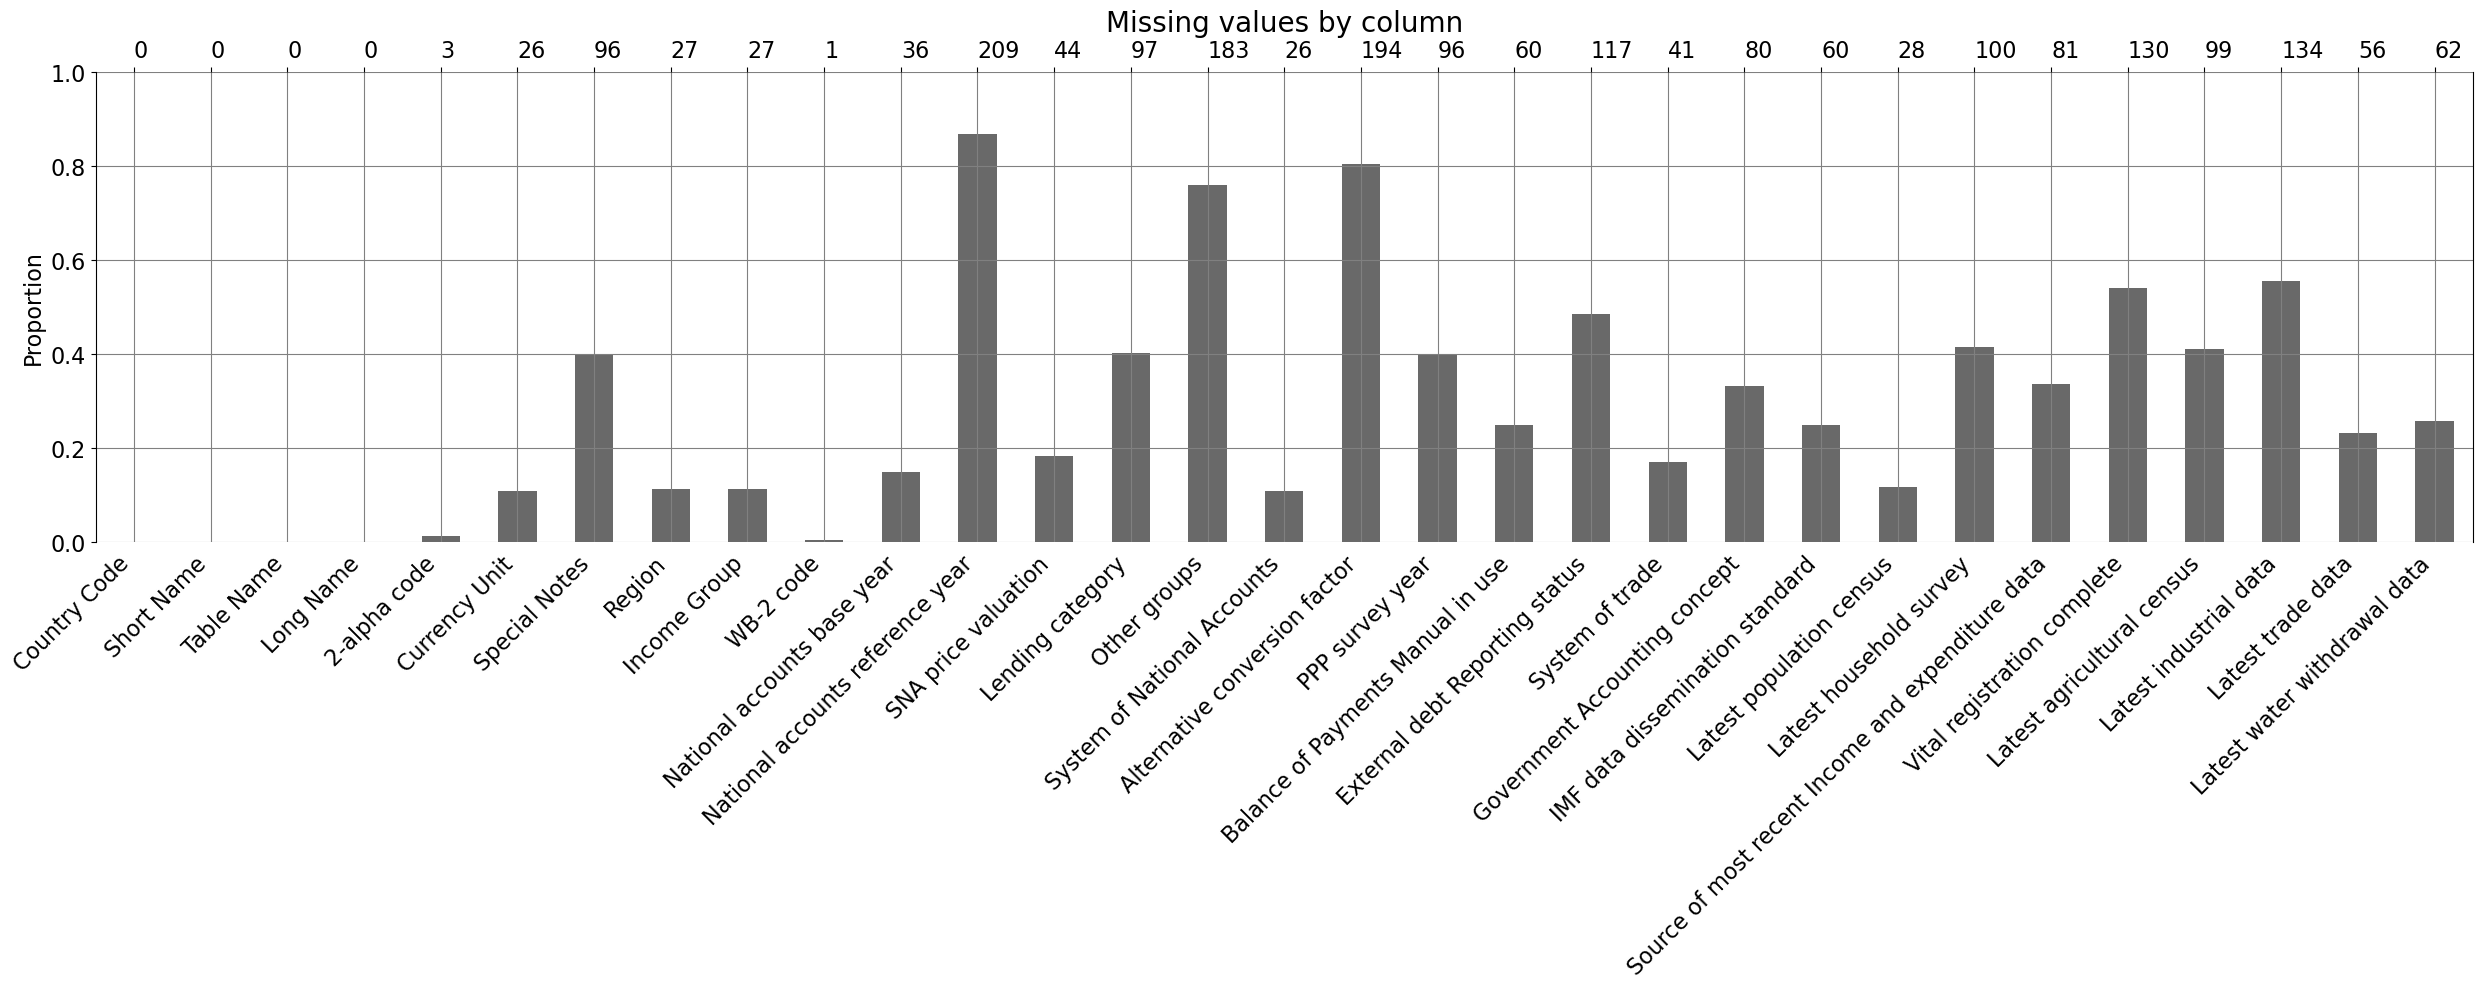

In [84]:
prop_missing = compute_and_plot_missing_values(country_df)

In [85]:
display(prop_missing)

Country Code                                          0.0
Short Name                                            0.0
Table Name                                            0.0
Long Name                                             0.0
2-alpha code                                          1.2
Currency Unit                                        10.8
Special Notes                                        39.8
Region                                               11.2
Income Group                                         11.2
WB-2 code                                             0.4
National accounts base year                          14.9
National accounts reference year                     86.7
SNA price valuation                                  18.3
Lending category                                     40.2
Other groups                                         75.9
System of National Accounts                          10.8
Alternative conversion factor                        80.5
PPP survey yea

**NOTE :** Pour aller plus loin dans la gestion des colonnes inutilisables, nous pouvons appliquer par exemple une condition. 
Ex : si une colonne a plus de n% de valeurs manquantes, alors on la supprime.
La case ci-dessous réalise cette tâche avec n = 75.

**Regarder comment gérer les valeurs manquantes**

In [86]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

country_df.drop(columns = columns_to_delete, inplace = True)


**NOTE IMPORTANTE POUR MOI-MÊME :** Pour supprimer des colonnes, il faut passer par un objet "hashable" - qui utilise une table de hash pour stocker les valeurs (dict, set, frozen set). Donc, utiliser une liste ou tuple ne fonctionne pas. *MAIS* les objets Index des DataFrame sont des objets hashables. 

Les statistiques descriptives de chaque colonne de type numérique ayant déjà été montrées plus haut, regardons le nombre d'occurence de chaque valeur des attributs "littéraux".

Pour cela, je vais d'abord sélectionner les attributs littéraux, puis un à un calculer l'occurrence des valeurs via value_counts. Et pour finir, les stocker dans un dictionnaire avec le nom des attributs comme index.
Je pourrais directement le faire sur le dataframe filtré en entier, mais je trouve le résultat peu lisible (cf case juste en dessous)

%% **QUESTION :** l'entièreté du dataFrame est prise en compte lors du df.value_counts() ? Est-ce qu'une occurrence est comptée comme double quand TOUTES les attributs sont identiques sur deux entrées ?    

In [87]:
#first_df.select_dtypes("object").value_counts()

In [88]:
occurences_country = count_cat_occurences(country_df)

# Ex : 
display(occurences_country["Government Accounting concept"])

Government Accounting concept
Consolidated central government    95
Budgetary central government       66
Name: count, dtype: int64

## Deuxième dataset

In [89]:
data_df = dfs_container["EdStatsData"]

data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

In [90]:
data_df.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


A première vue, le DataFrame représente l'évolution de différents indicateurs à travers les ans (1970 -> 2100). 
On peut alors supposer qu'une partie des attributs est une donnée mesurée, et l'autre est projetée.

Concernant le type des attributs, seuls 4 sont littéraux, le reste étant numériques. Cela fait sens, les 2 premiers sont le code et le nom de pays, les deux suivants sont les indicateurs et leurs codes.

Comme tous les indicateurs sont mélangés, il est difficile de faire des observations quant aux statistiques descriptives sur le dataset initial. On peut néanmoins regarder si d'éventuels doublons sont disséminés parmi les données.

In [91]:
compute_number_of_unique_entries(data_df)

Le nombre d'entrée unique est de 886930, sur 886930 entrées au total. Soit 0% de doublons


A priori, aucun doublon. On peut déjà supprimer la dernière colonne (Unnamed: 69), qui ne comprend aucune donnée. Suite à cela, on calculera la proportion de données manquantes par attribut

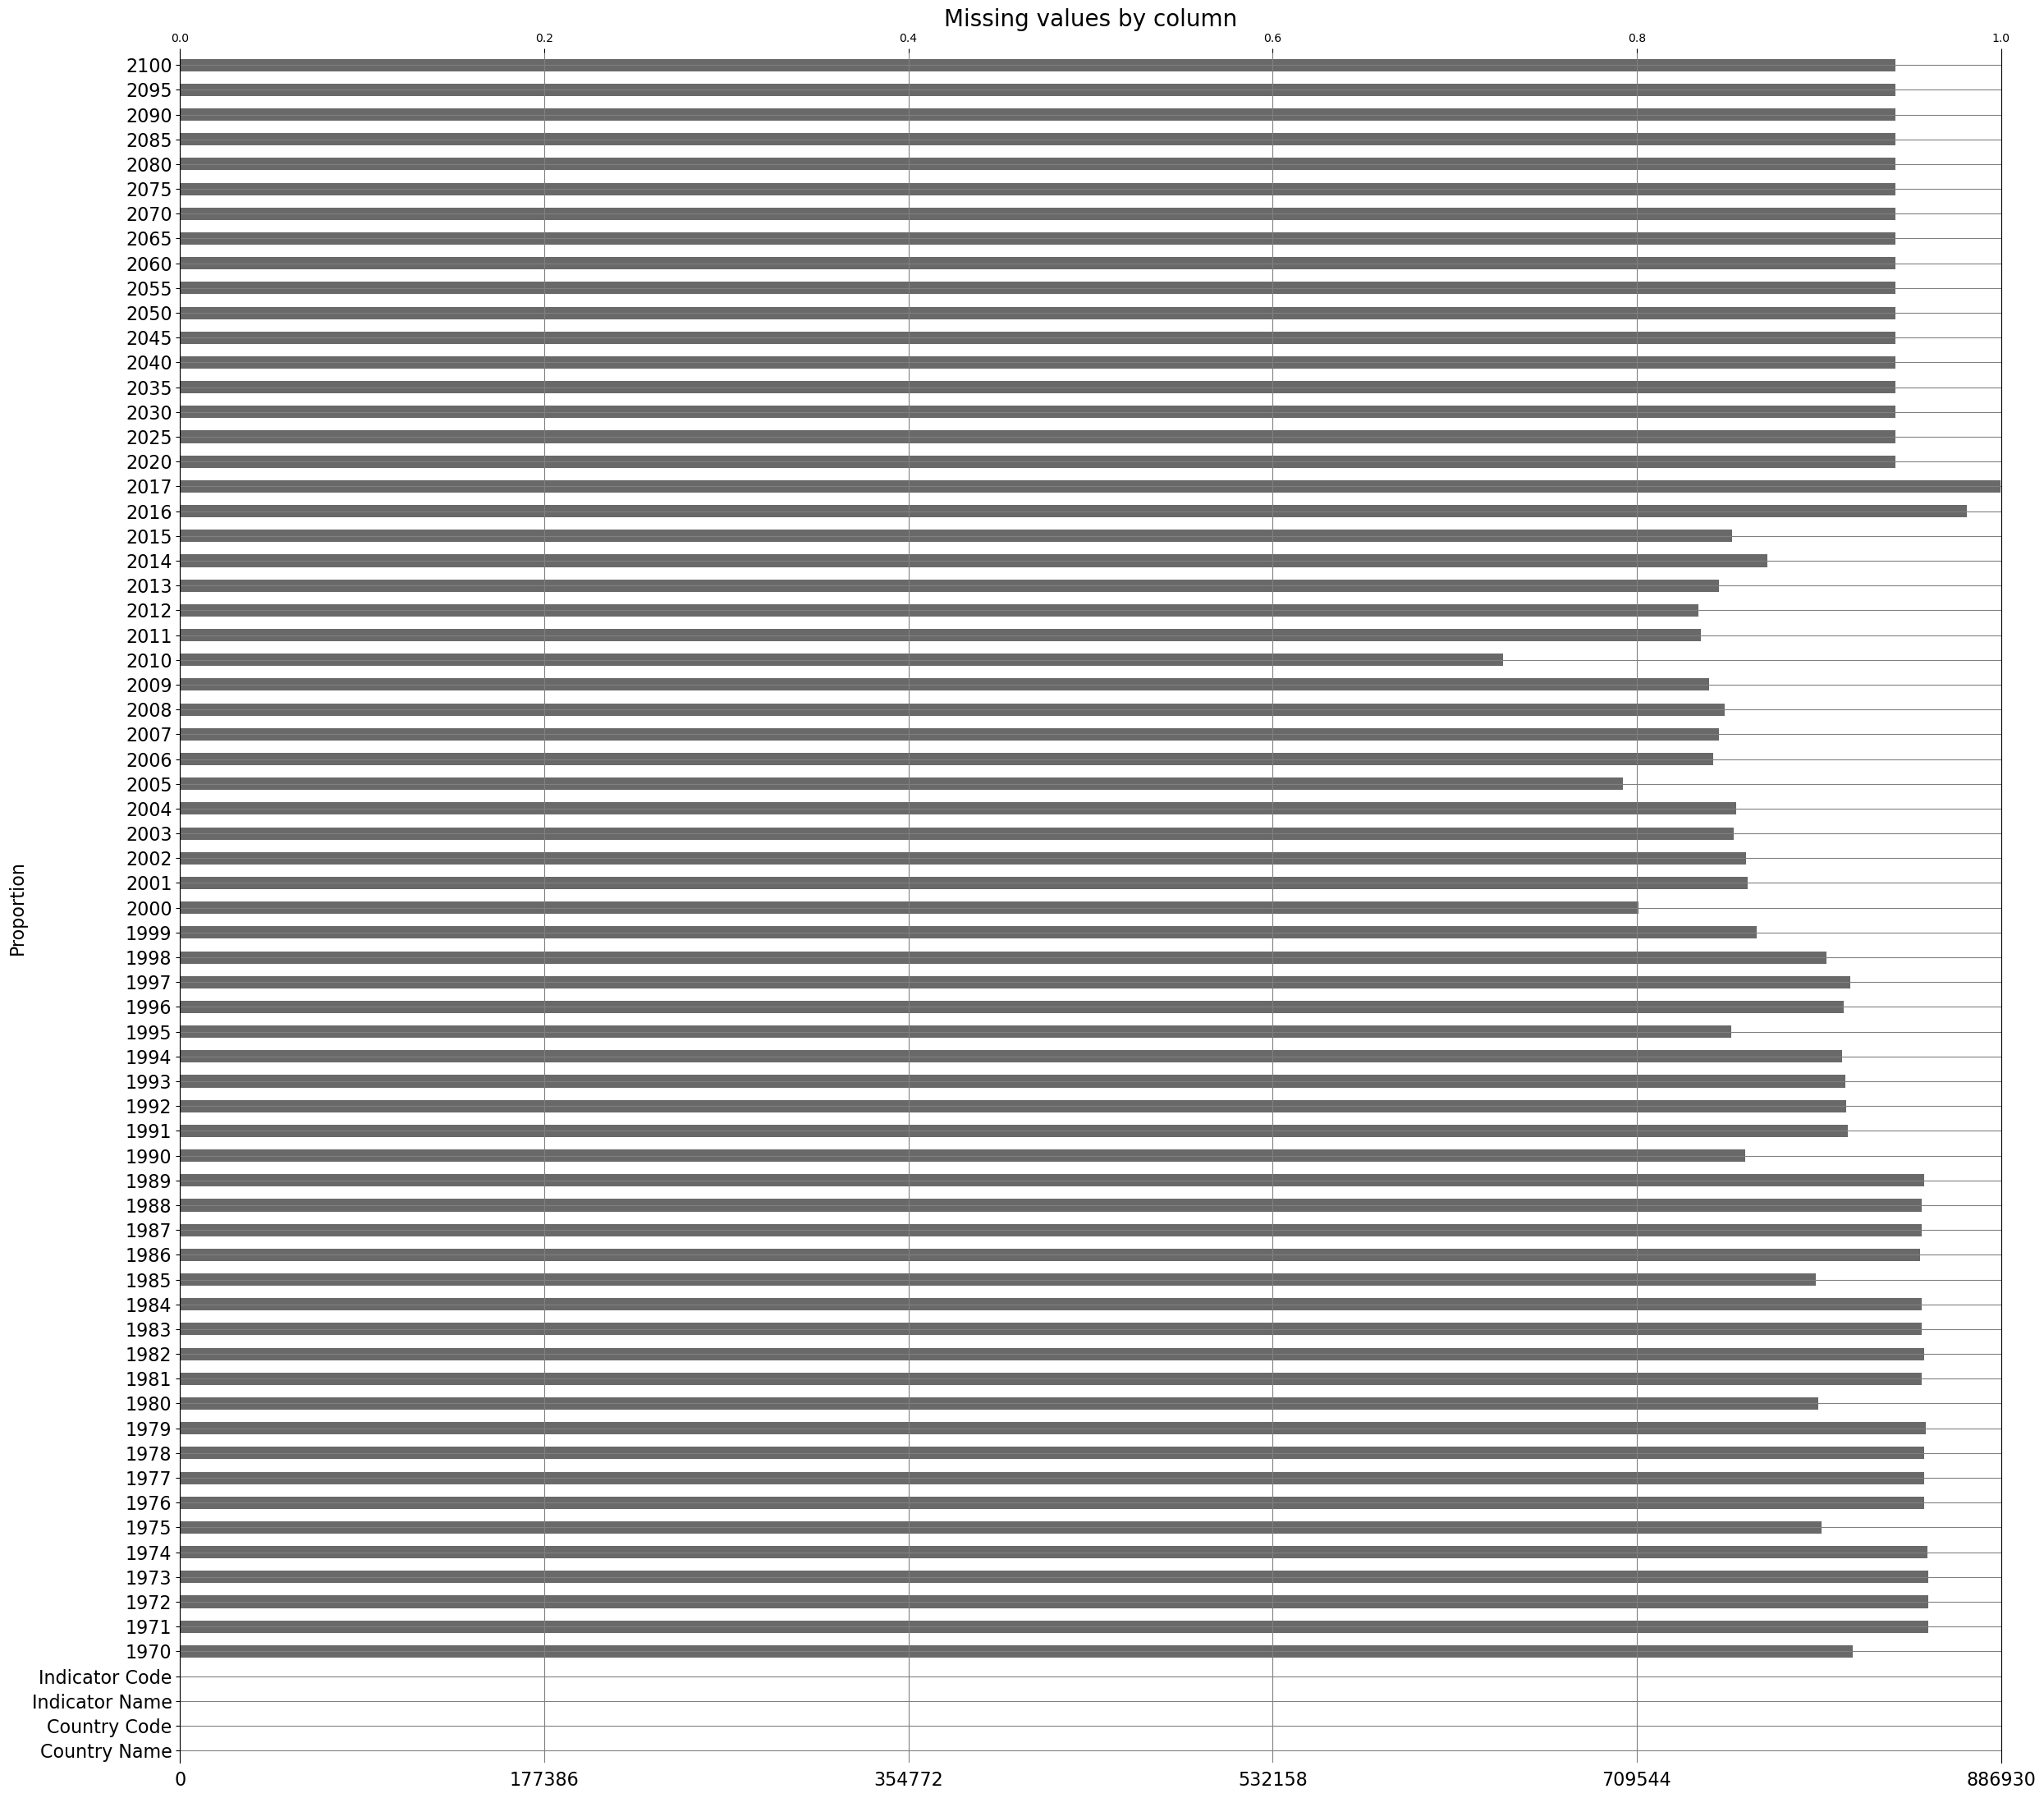

In [92]:
data_df.drop(columns = "Unnamed: 69", inplace= True)

prop_missing = compute_and_plot_missing_values(data_df)

In [93]:
display(prop_missing)

Country Name       0.0
Country Code       0.0
Indicator Name     0.0
Indicator Code     0.0
1970              91.8
                  ... 
2080              94.2
2085              94.2
2090              94.2
2095              94.2
2100              94.2
Length: 69, dtype: float64

In [94]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

display(data_df.drop(columns = columns_to_delete))

,Country Name,Country Code,Indicator Name,Indicator Code,2010
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,85.211998
...,...,...,...,...,...
886925,Zimbabwe,ZWE,"Youth illiterate population, 15-24 years, male...",UIS.LP.AG15T24.M,NaN
886926,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, b...",SE.ADT.1524.LT.ZS,NaN
886927,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, f...",SE.ADT.1524.LT.FE.ZS,NaN
886928,Zimbabwe,ZWE,"Youth literacy rate, population 15-24 years, g...",SE.ADT.1524.LT.FM.ZS,NaN


Cela ne nous avance pas beaucoup. Si l'on suit le raisonnement évoqué avec le premier dataset, la quasi-totalité des attributs numériques sont à supprimer par manque d'information. Tout supprimer enlèverait beaucoup d'informations et potentiellement de l'information utile.

Un autre raisonnement serait de vérifier non pas les attributs ayant beaucoup de valeurs manquantes, mais plutôt les entrées.
En effet, si certains indicateurs n'ont que très peu d'entrées concernées, alors ceux-là sont réellement fautifs du manque d'information.

Pour cela, on peut grouper le DataFrame par indicateur.

In [95]:
#num_attributes = list(second_df.select_dtypes("float64").columns)
#test=second_df.groupby(["Indicator Name"])[num_attributes].count()
#test



In [96]:
###### A COMPLETER

#nbr_values = np.array(test.replace(0,np.nan).count())
#nbr_max_values = len(list(second_df.columns))

#proportion_missing = np.round((1 - (nbr_values / np.max(nbr_values)))*100, decimals = 1)
#proportion_missing


#prop_missing_per_indicator = zip(indicator, proportion_missing)
#prop_missing_per_column = pd.DataFrame(prop_missing_per_column, columns = ["attributes", "missing_values"]).set_index("attributes")
#display(prop_missing_per_column)

#nbr_values

Suite à cela, nous pouvons calculer le nombre d'occurrences de chaque colonne catégorielle selon :

In [97]:
occurences_data = count_cat_occurences(data_df)

# Ex : 
occurences_data["Country Name"]

Country Name
Arab World                                     3665
East Asia & Pacific                            3665
East Asia & Pacific (excluding high income)    3665
Euro area                                      3665
Europe & Central Asia                          3665
                                               ... 
Virgin Islands (U.S.)                          3665
West Bank and Gaza                             3665
Yemen, Rep.                                    3665
Zambia                                         3665
Zimbabwe                                       3665
Name: count, Length: 242, dtype: int64

## Troisième dataset

In [98]:
series_df = dfs_container["EdStatsSeries"]

display(series_df.head(3))

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,...,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
series_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

In [100]:
series_df.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


Selon df.info(), nous avons 6 attributs numériques et 15 attributs catégoriels. De plus, les attributs numériques sont exempts de données, étant remplis de NaN. Ce faisant, nous pouvons les supprimer.

In [101]:
num_col = list(series_df.select_dtypes("float64"))
series_df.drop(columns=num_col,inplace=True)
series_df

,Series Code,Topic,Indicator Name,Short definition,Long definition,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,General comments,Source,Statistical concept and methodology,Development relevance,Related source links
0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN
3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,Secondary,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN


La proportion de données manquantes par colonne est de : 

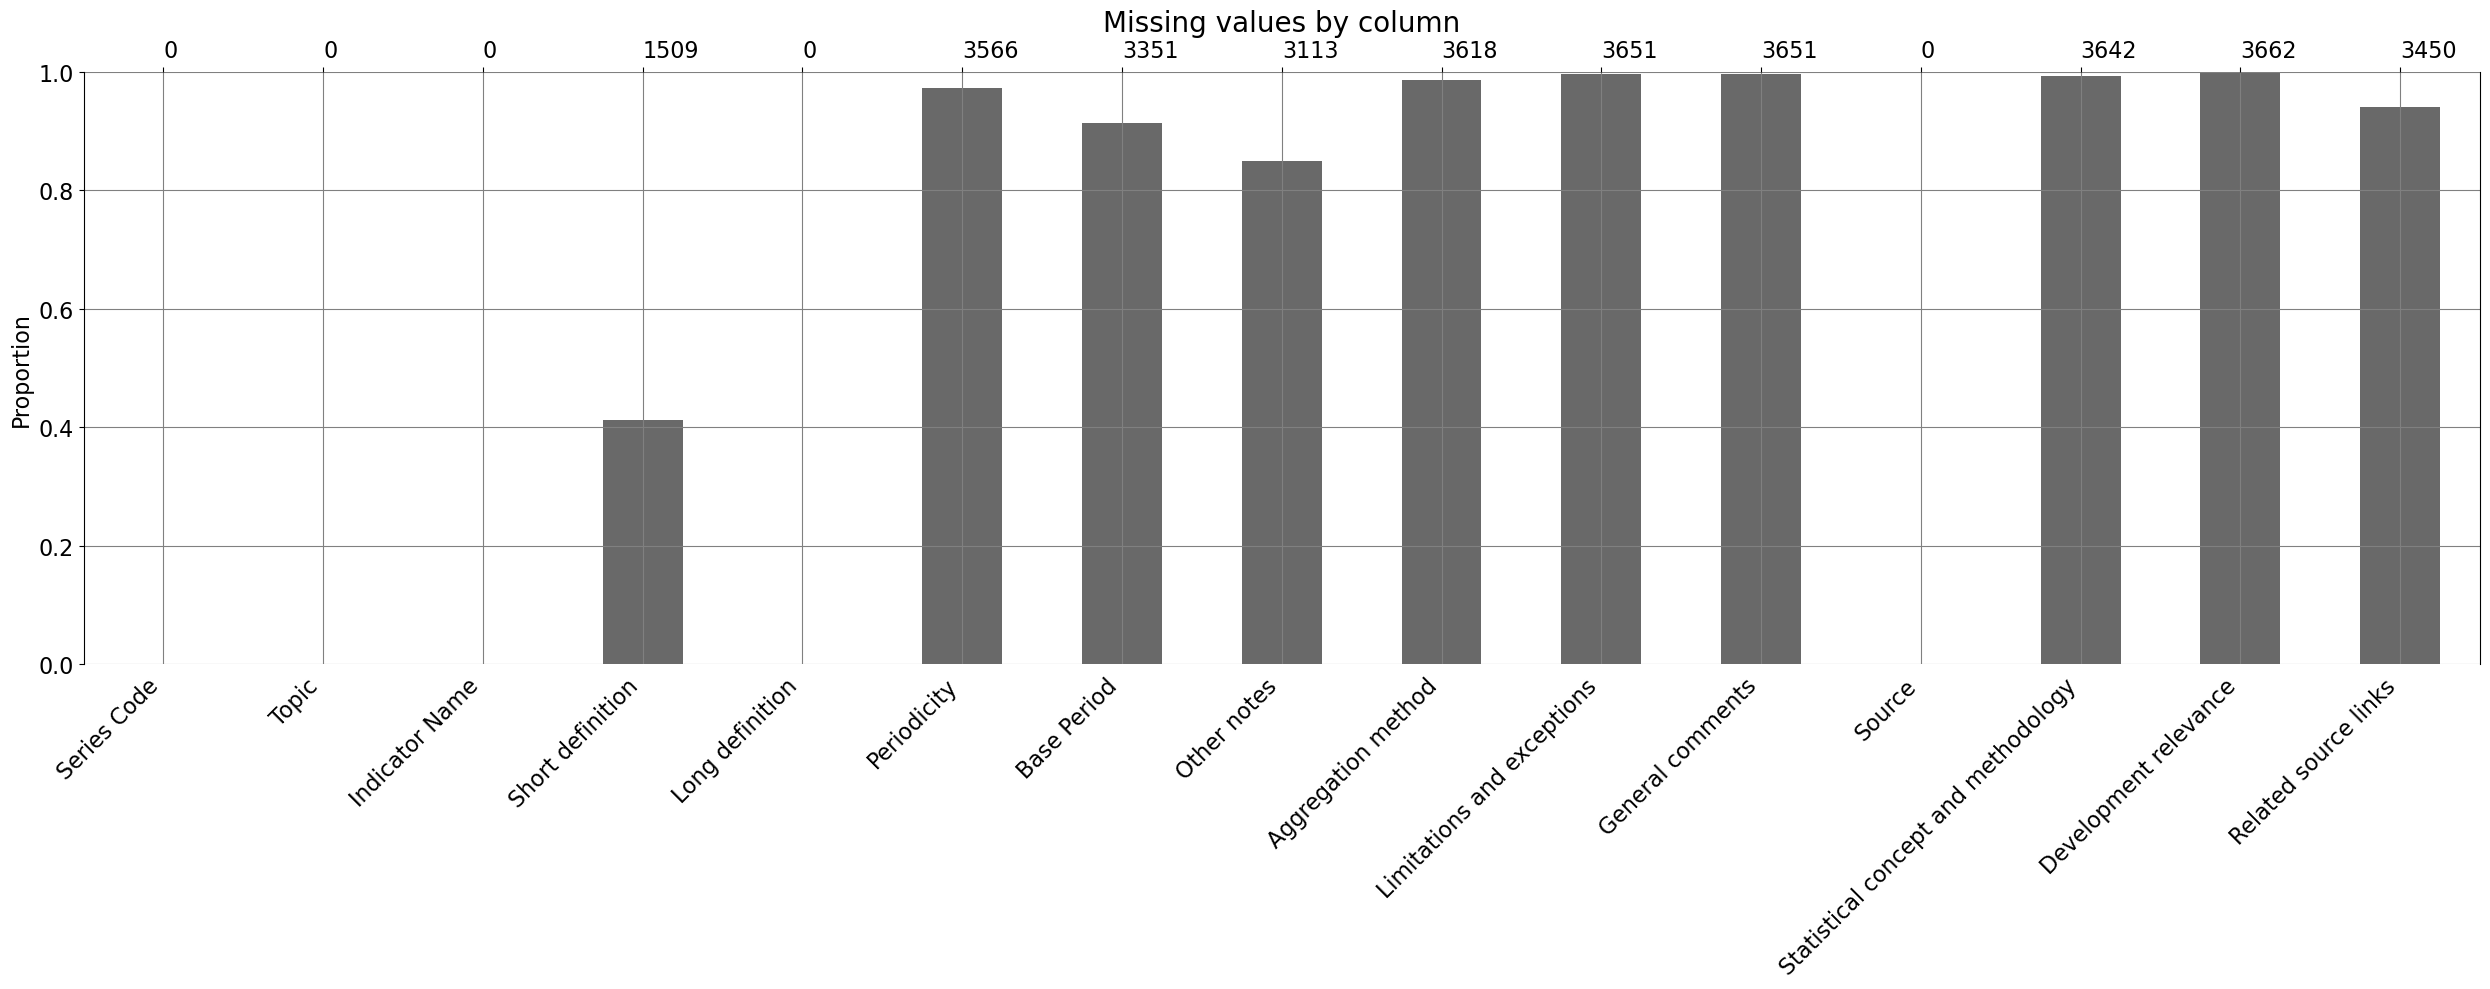

In [102]:
prop_missing = compute_and_plot_missing_values(series_df)

In [103]:
display(prop_missing)

Series Code                             0.0
Topic                                   0.0
Indicator Name                          0.0
Short definition                       41.2
Long definition                         0.0
Periodicity                            97.3
Base Period                            91.4
Other notes                            84.9
Aggregation method                     98.7
Limitations and exceptions             99.6
General comments                       99.6
Source                                  0.0
Statistical concept and methodology    99.4
Development relevance                  99.9
Related source links                   94.1
dtype: float64

Étant donné que la majorité des attributs ayant des données manquantes ont un taux > 80 %, je fais le choix de supprimer celles remplissant la condition. J'y ajoute également l'attribut "Short definition", car il est redondant avec "Long definition"

In [104]:
columns_to_delete = get_columns_to_delete(prop_missing, 75)

series_df.drop(columns = columns_to_delete, inplace = True)

Enfin, je calcule le nombre d'occurrences par colonne catégorielle : 

In [105]:
val_occurences_series = count_cat_occurences(series_df)

display(val_occurences_series["Topic"])

Topic
Learning Outcomes                                                                               1046
Attainment                                                                                       733
Education Equality                                                                               426
Secondary                                                                                        256
Primary                                                                                          248
Population                                                                                       213
Tertiary                                                                                         158
Teachers                                                                                         137
Expenditures                                                                                      93
Engaging the Private Sector (SABER)                                                  

## Quatrième dataset

In [106]:
country_series_df = dfs_container["EdStatsCountry-Series"]

display(country_series_df.head(3))

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN


In [107]:
country_series_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CountryCode  613 non-null    object 
 1   SeriesCode   613 non-null    object 
 2   DESCRIPTION  613 non-null    object 
 3   Unnamed: 3   0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 19.3+ KB


In [108]:
country_series_df.describe()

,Unnamed: 3
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Le quatrième dataset possède 3 attributs catégoriels et un numérique. Le seul attribut numérique est inutilisable, il est donc à supprimer.
Avec ceci, on peut regarder le nombre de doublons éventuels

In [109]:
country_series_df.drop(columns="Unnamed: 3", inplace=True)

In [110]:
compute_number_of_unique_entries(country_series_df)

Le nombre d'entrée unique est de 613, sur 613 entrées au total. Soit 0% de doublons


Finalement, le nombre d'occurrences de chaque valeur dans chaque attribut catégoriciel : 

In [111]:
val_occurences_country_series = count_cat_occurences(country_series_df)

display(val_occurences_country_series["DESCRIPTION"])

DESCRIPTION
Data sources : United Nations World Population Prospects                                              154
Data sources: United Nations World Population Prospects                                               137
Estimates are based on regression.                                                                     84
Data sources : Eurostat                                                                                54
Derived using ratio of age group from WPP and World Bank population.                                   24
                                                                                                     ... 
Data sources : U.S. Census Bureau, United Nations Population and Vital Statistics Report                1
Data sources: General Statistics Office of Vietnam                                                      1
Data sources : General Statistics Office of Vietnam                                                     1
Data sources : World Bank's Kosovo

## Cinquième dataset

In [112]:
footnote_df = dfs_container["EdStatsFootNote"]

display(footnote_df.head(3))

,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN


In [113]:
footnote_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB


In [114]:
footnote_df.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


Le cinquième dataset est assez semblable au quatrième. Un seul attribut numérique inutilisable, et 3 catégoriels. On reprend donc les mêmes opérations ci-dessous

In [115]:
footnote_df.drop(columns="Unnamed: 4", inplace=True)

In [116]:
compute_number_of_unique_entries(footnote_df)

Le nombre d'entrée unique est de 643638, sur 643638 entrées au total. Soit 0% de doublons


In [117]:
val_occurences_footnote = count_cat_occurences(footnote_df)

display(val_occurences_footnote["DESCRIPTION"])

DESCRIPTION
Country Data                                      191188
UNESCO Institute for Statistics (UIS) estimate    171527
Estimated                                         117155
UIS Estimation                                     31395
Country estimation.                                26308
                                                   ...  
Uncertainty bound is 27.3 - 48.2                       1
Uncertainty bound is 64.6 - 83.8                       1
Uncertainty bound is 55.7 - 68.3                       1
Uncertainty bound is 63.5 - 83                         1
Uncertainty bound is 59.8 - 76.1                       1
Name: count, Length: 9102, dtype: int64

# Etape 3 - Filtrage des datasets

Objectif : Filtrer les faux pays  

***DISCLAIMER :*** La définition de pays ici englobe tout État n'étant pas un agglomérat. 
On acceptera donc le Kosovo ou les Channel Islands, qui ne sont pas des pays à proprement parlé.

De cette manière, on peut filtrer toute entrée du dataset country où l'attribut région est vide. 

In [118]:
country_only_df = country_df.dropna(subset=["Region"])
country_only_df

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,...,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,...,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,...,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,...,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,...,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,XKX,Kosovo,Kosovo,Republic of Kosovo,NaN,Euro,"Kosovo became a World Bank member on June 29, ...",Europe & Central Asia,Lower middle income,KV,...,NaN,General Data Dissemination System (GDDS),2011,NaN,"Integrated household survey (IHS), 2011",NaN,NaN,NaN,NaN,NaN
237,YEM,Yemen,"Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,Based on official government statistics and In...,Middle East & North Africa,Lower middle income,RY,...,Budgetary central government,General Data Dissemination System (GDDS),2004,"Demographic and Health Survey (DHS), 2013","Expenditure survey/budget survey (ES/BS), 2005",NaN,NaN,2006.0,2012.0,2005
238,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2011,"Demographic and Health Survey (DHS), 2003; Wor...","Expenditure survey/budget survey (ES/BS), 2010",NaN,2007,2010.0,2012.0,2000
239,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data have rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,General Data Dissemination System (GDDS),2010,"Demographic and Health Survey (DHS), 2013","Integrated household survey (IHS), 2010",NaN,2010. Population and Housing Census.,NaN,2011.0,2002


Pour la suite de l'exercice, je vais éliminer les entrées ne correspondant pas à des pays pour les supprimer dans les autres dataset. 
Deux manières : 

- En stockant les faux pays dans une liste qui sera utilisée pour le filtrage des différents dataframes.
- En utilisant un inner join entre les pays du dataframe Country nettoyé, et les autres dataframes.

In [150]:
#Je stocke les agglomérats dans une liste, autrement dit je les blacklist
not_a_country_list = list(country_df["Country Code"][country_df["Region"].isna()].values)

# Je filtre mon dataset en prenant TOUS les pays n'étant pas dans ma blacklist
clean_country_df = country_df[~country_df["Country Code"].isin(not_a_country_list)]
clean_country_df = clean_country_df.set_index("Country Code")
col_name = "Country Code"

#Je vais comparer directement filtrage par liste et jointure 
for key, df in dfs_container.items():
    if key not in ["EdStatsSeries", "EdStatsCountry" ] : # Series car pas de Country Code, Country car impossible de joindre sur lui-même
        if col_name not in list(df.columns): 
            df.rename(columns={"CountryCode": col_name}, inplace = True)
        
        list_filtered = df[
            ~df["Country Code"].isin(not_a_country_list)   #Filtrage par liste
        ]

        join_filtered = df.join(          #Filtrage par join
            clean_country_df,
            how="inner",
            on="Country Code"
        )

        print(
            key,
            "->",
            len(list_filtered),
            len(join_filtered),
            "OK" if len(list_filtered) == len(join_filtered) else "DIFF"
        )

EdStatsData -> 787975 784310 DIFF
EdStatsCountry-Series -> 611 611 OK
EdStatsFootNote -> 516743 515752 DIFF


Bien que les deux filtrages aient été opérés, on remarque une différence de résultats dans EdStatsData et EdStatsFootNote.

Cette différence peut être expliquée par la manière de filtrer de chacun :

– Filtrage par liste : TOUS les codes n'étant PAS dans ma liste sont gardés.
– Filtrage par .join() : UNIQUEMENT les codes présents dans les deux DataFrame sont gardés.

Cette différence se voit lorsque de nouvelles valeurs apparaissent dans le dataset à traiter.

– Filtrage par liste : la nouvelle valeur sera acceptée, car elle ne fait pas partie de la "blacklist".
– Filtrage par .join() : la nouvelle valeur sera supprimée, puisqu'elle est sans correspondance avec le dataset de référence.

Cas de EdStatsFootNote : 

In [149]:
df = dfs_container["EdStatsFootNote"]

list_filtered = df[
    ~df["Country Code"].isin(not_a_country_list)
]

codes_in_list = set(list_filtered["Country Code"])
codes_in_join = set(clean_country_df.index)

print("Dans liste mais pas dans join :")
print(codes_in_list - codes_in_join)

print("\nNombre de codes concernés :")
print(len(codes_in_list - codes_in_join))

print("\nNombre de lignes concernées :")
print(df["Country Code"].value_counts().loc["VGB"])

Dans liste mais pas dans join :
{'VGB'}

Nombre de codes concernés :
1

Nombre de lignes concernées :
991
